# Logistic Regression — From Theory to Code

In our Linear Regression notebooks, we predicted **continuous numbers** (like Ice Cream Revenue or Home Goals).

But what if the thing we want to predict is a **category**?
- Is this email **Spam** or **Not Spam**?
- Will the patient **Survive** or **Not Survive**?
- Will the home team **Win** or **Lose**?

These are **Classification** problems, and the simplest, most foundational algorithm for solving them is **Logistic Regression**.

> **Important:** Despite having "Regression" in its name, Logistic Regression is a **Classification** algorithm. The name comes from the fact that it uses the same linear equation as Linear Regression internally, but wraps it in a special function to output probabilities.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


---
## 1. The Problem with Linear Regression for Classification

Linear Regression outputs **any number** on the number line: $-\infty$ to $+\infty$.

But for classification, we need an output between **0 and 1** that we can interpret as a **probability**.

If the model says `0.92`, we read that as: *"I am 92% confident this belongs to Class 1."*

We need a mathematical function that takes any number and **squashes** it into the range [0, 1]. That function is the **Sigmoid Function**.

---
## 2. The Sigmoid Function

The Sigmoid function (also written as $\sigma$) is:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
- $z$ is the raw output from the linear equation ($z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots$)
- $e$ is Euler's number (~2.718), the base of the natural logarithm

No matter what number you feed in — whether it's `-1000`, `0`, or `+1000` — the Sigmoid **always** outputs a value between 0 and 1.

Let's implement and visualize it!

In [3]:
def sigmoid(z):
    """The Sigmoid Function: squashes any number into the range (0, 1)"""
    return 1 / (1 + np.exp(-z))

# Test it with a few values
print(f"sigmoid(-1000) = {sigmoid(-1000):.4f}  (basically 0)")
print(f"sigmoid(-2)    = {sigmoid(-2):.4f}")
print(f"sigmoid(0)     = {sigmoid(0):.4f}   (exactly 0.5 — the tipping point!)")
print(f"sigmoid(2)     = {sigmoid(2):.4f}")
print(f"sigmoid(1000)  = {sigmoid(1000):.4f}  (basically 1)")

sigmoid(-1000) = 0.0000  (basically 0)
sigmoid(-2)    = 0.1192
sigmoid(0)     = 0.5000   (exactly 0.5 — the tipping point!)
sigmoid(2)     = 0.8808
sigmoid(1000)  = 1.0000  (basically 1)


/tmp/ipykernel_795664/2999637923.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


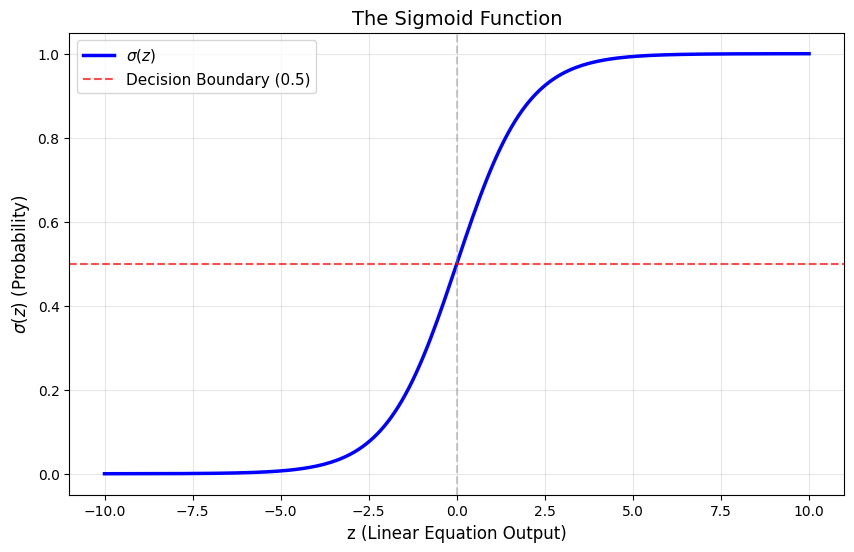

In [4]:
# --- Visualize the Sigmoid Curve ---
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, color='blue', linewidth=2.5, label='$\sigma(z)$')

# Draw the decision boundary at 0.5
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Boundary (0.5)')
plt.axvline(x=0,   color='gray', linestyle='--', alpha=0.4)

plt.title('The Sigmoid Function', fontsize=14)
plt.xlabel('z (Linear Equation Output)', fontsize=12)
plt.ylabel('$\sigma(z)$ (Probability)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Notice the beautiful S-shaped curve! The key takeaways are:
- Large positive inputs → probability close to **1**
- Large negative inputs → probability close to **0**
- An input of 0 → probability of exactly **0.5** (the model is completely unsure)

The **decision rule** is:
- If $\sigma(z) \geq 0.5$ → predict **Class 1**
- If $\sigma(z) < 0.5$ → predict **Class 0**

---
## 3. The Full Logistic Regression Equation

Logistic Regression is literally **Linear Regression wrapped inside the Sigmoid**:

$$\hat{y} = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n)$$

Which expands to:

$$\hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots)}}$$

So the model still learns weights ($\beta$) for every feature, just like `MyLinReg`. The only difference is that the final answer gets squeezed through the Sigmoid before being returned.

---
## 4. The Loss Function: Binary Cross-Entropy (Log Loss)

### Why can't we use MSE?

In Linear Regression, we used **Mean Squared Error** (MSE) to measure how wrong our model was.

If we try to use MSE with the Sigmoid, we get a **non-convex** loss surface. Remember our "walking down the mountain" analogy from Gradient Descent? A non-convex surface has **multiple valleys and bumps**. Gradient Descent could get stuck in a shallow valley (a **local minimum**) and never reach the deepest valley (the **global minimum**).

To fix this, we use a mathematically elegant loss function called **Binary Cross-Entropy Loss** (or **Log Loss**):

$$J(\theta) = -\frac{1}{n}\sum_{i=1}^{n}\left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]$$

This formula uses the **natural log** ($\log$) function. Why? Because $-\log(x)$ has a very special property:
- When $x$ is close to 1 → $-\log(x)$ is close to **0** (small penalty)
- When $x$ is close to 0 → $-\log(x)$ shoots to **infinity** (massive penalty)

This means the loss function **severely punishes confident wrong predictions**.

Let's visualize this:

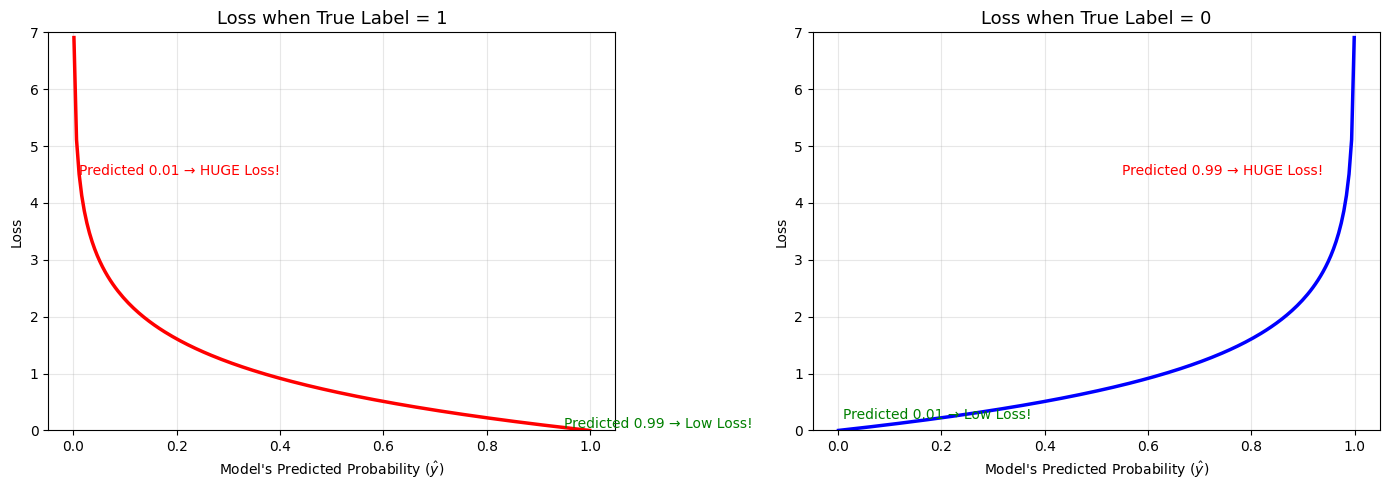

In [7]:
# --- Visualize the Log Loss Penalty ---
y_hat = np.linspace(0.001, 0.999, 200)  # predicted probabilities (avoid log(0))

# Loss when TRUE answer is 1
loss_when_y_is_1 = -np.log(y_hat)

# Loss when TRUE answer is 0
loss_when_y_is_0 = -np.log(1 - y_hat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: True label = 1
axes[0].plot(y_hat, loss_when_y_is_1, color='red', linewidth=2.5)
axes[0].set_title('Loss when True Label = 1', fontsize=13)
axes[0].set_xlabel('Model\'s Predicted Probability ($\hat{y}$)')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(0, 7)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Predicted 0.99 → Low Loss!', xy=(0.95, 0.05), fontsize=10, color='green')
axes[0].annotate('Predicted 0.01 → HUGE Loss!', xy=(0.01, 4.5), fontsize=10, color='red')

# Right plot: True label = 0
axes[1].plot(y_hat, loss_when_y_is_0, color='blue', linewidth=2.5)
axes[1].set_title('Loss when True Label = 0', fontsize=13)
axes[1].set_xlabel('Model\'s Predicted Probability ($\hat{y}$)')
axes[1].set_ylabel('Loss')
axes[1].set_ylim(0, 7)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Predicted 0.01 → Low Loss!', xy=(0.01, 0.20), fontsize=10, color='green')
axes[1].annotate('Predicted 0.99 → HUGE Loss!', xy=(0.55, 4.5), fontsize=10, color='red')

plt.tight_layout()
plt.show()

### Reading the charts:

**Left Chart (True Label = 1):**
- If the model predicts 0.99 (correctly confident) → Loss is nearly 0. Great!
- If the model predicts 0.01 (confidently WRONG) → Loss is massive (~4.6). Terrible!

**Right Chart (True Label = 0):**
- If the model predicts 0.01 (correctly confident it's NOT class 1) → Loss is nearly 0.
- If the model predicts 0.99 (confidently says it IS class 1, but it's not) → Loss is massive.

The key insight: **Being confidently wrong is punished exponentially harder than being vaguely wrong.** This forces the model to be very careful.

---
## 5. Training with Gradient Descent

Just like our `MyMultipleLinRegGD` class, Logistic Regression uses Gradient Descent to find the optimal weights.

The update rule is identical in structure:

$$\boldsymbol{\theta}_{new} = \boldsymbol{\theta}_{old} - \alpha \cdot \frac{1}{m} \mathbf{X}^T (\hat{y} - y)$$

The **only** difference from Linear Regression is how $\hat{y}$ is calculated:
- Linear Regression: $\hat{y} = X\theta$
- Logistic Regression: $\hat{y} = \sigma(X\theta)$

The Sigmoid's derivative simplifies perfectly, so the gradient formula looks exactly the same! All the magic happens inside `sigmoid()`.

---
## 6. Building it from Scratch!

Let's build our own `MyLogisticRegression` class, following the same structure as our Linear Regression class.

In [10]:
class MyLogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None
        self.loss_history = []  # We'll track the loss over time to visualize learning

    def _sigmoid(self, z):
        """The Sigmoid function"""
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y, y_hat):
        """Binary Cross-Entropy Loss"""
        # np.clip prevents log(0) which would give -infinity
        y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))    # the log-loss

    def fit(self, X_train, y_train):
        # Add the bias column of 1s
        X_train_b = np.insert(X_train, 0, 1, axis=1)
        m = X_train_b.shape[0]

        # Initialize all weights to zero
        betas = np.zeros(X_train_b.shape[1])

        # Gradient Descent loop
        for epoch in range(self.epochs):
            # Step 1: Calculate the raw linear output
            z = np.dot(X_train_b, betas)

            # Step 2: Squeeze it through the Sigmoid → probabilities!
            y_hat = self._sigmoid(z)

            # Step 3: Calculate and store the loss
            loss = self._compute_loss(y_train, y_hat)
            self.loss_history.append(loss)

            # Step 4: Calculate the gradient (same formula as Linear Regression!)
            gradient = (1 / m) * np.dot(X_train_b.T, (y_hat - y_train))

            # Step 5: Update the weights
            betas = betas - (self.lr * gradient)

        # Extract intercept and coefficients
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict_proba(self, X_test):
        """Returns the raw probability (between 0 and 1)"""
        z = np.dot(X_test, self.coef_) + self.intercept_
        return self._sigmoid(z)

    def predict(self, X_test):
        """Returns the final class label: 0 or 1"""
        probabilities = self.predict_proba(X_test)
        return (probabilities >= 0.5).astype(int)


### Key differences from `MyLinReg`:
1. Added `_sigmoid()` method to squash the linear output into probabilities.
2. Added `_compute_loss()` for the Binary Cross-Entropy formula.
3. `predict_proba()` returns the raw probability (0 to 1).
4. `predict()` applies the threshold: if probability >= 0.5, predict 1, else predict 0.
5. `loss_history` tracks the loss at every epoch so we can plot the "learning curve."

---
## 7. Testing on a Real(ish) Dataset

Let's generate a binary classification dataset using Scikit-Learn and test our custom model against the official one!

In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate a fake binary classification dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,       # Only 2 features so we can visualize it!
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# IMPORTANT: Scale the features so Gradient Descent doesn't explode!
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")
print(f"Classes:          {np.unique(y)}")

Training samples: 400
Testing samples:  100
Features:         2
Classes:          [0 1]


### Visualize the raw data
Since we only have 2 features, we can plot the two classes directly on a 2D scatter plot!

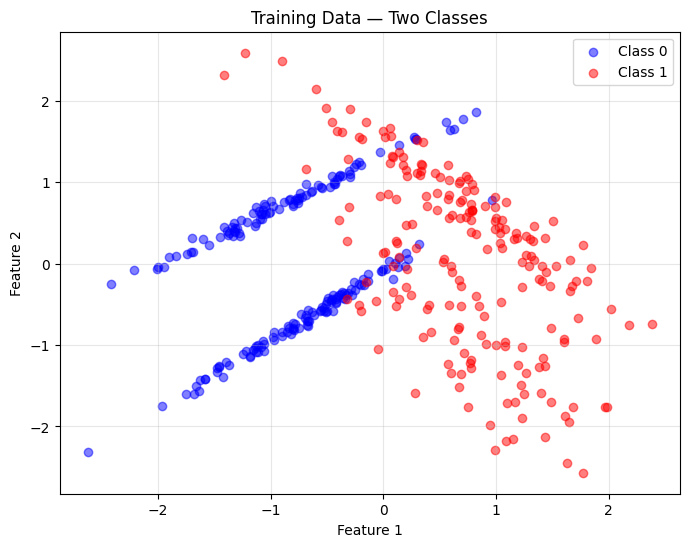

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', alpha=0.5, label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.5, label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data — Two Classes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We can visually see that the two classes are somewhat separable. Our Logistic Regression model's job is to find the **straight line** (called the **Decision Boundary**) that best separates the blue dots from the red dots.

---
## 8. Train the Model

In [13]:
# Train our custom model
my_model = MyLogisticRegression(learning_rate=0.1, epochs=2000)
my_model.fit(X_train, y_train)

print(f"Intercept: {my_model.intercept_:.4f}")
print(f"Coefficients: {my_model.coef_}")

Intercept: 0.0261
Coefficients: [3.59630698 0.49596031]


### The Learning Curve
Because we tracked `loss_history`, we can now plot how the loss decreased over time. This proves that Gradient Descent is working and the model is learning!

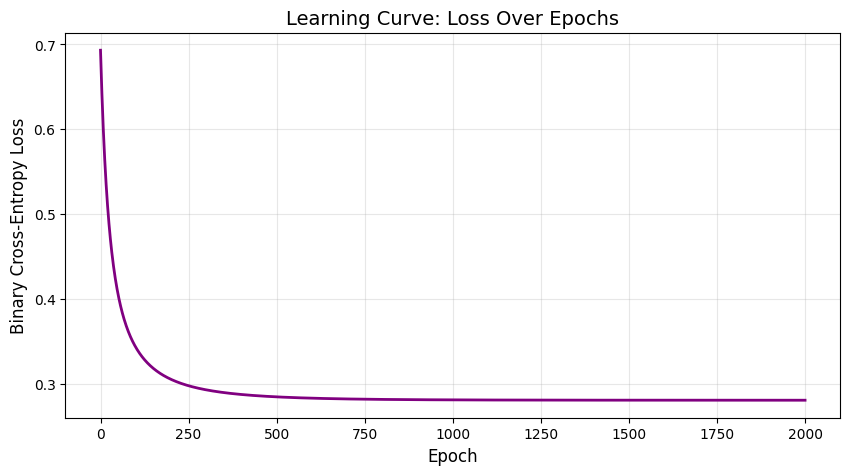

Starting Loss: 0.6931
Final Loss:    0.2811


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(my_model.loss_history, color='purple', linewidth=2)
plt.title('Learning Curve: Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Starting Loss: {my_model.loss_history[0]:.4f}")
print(f"Final Loss:    {my_model.loss_history[-1]:.4f}")

The loss should start high (the model is guessing randomly) and gradually drop as it learns the optimal weights. If the curve flattens out, the model has **converged** — it has found the valley!

---
## 9. Evaluate: Custom Model vs. Scikit-Learn

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Our Custom Model ---
my_preds = my_model.predict(X_test)
my_accuracy = accuracy_score(y_test, my_preds)

# --- Scikit-Learn's Model ---
sk_model = LogisticRegression(random_state=42)
sk_model.fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_preds)

print("=" * 45)
print("         MODEL COMPARISON")
print("=" * 45)
print(f"{'':15} {'Custom':>12} {'Sklearn':>12}")
print("-" * 45)
print(f"{'Intercept':15} {my_model.intercept_:>12.4f} {sk_model.intercept_[0]:>12.4f}")
print(f"{'Coef 1':15} {my_model.coef_[0]:>12.4f} {sk_model.coef_[0][0]:>12.4f}")
print(f"{'Coef 2':15} {my_model.coef_[1]:>12.4f} {sk_model.coef_[0][1]:>12.4f}")
print(f"{'Accuracy':15} {my_accuracy:>11.2%} {sk_accuracy:>11.2%}")
print("=" * 45)

         MODEL COMPARISON
                      Custom      Sklearn
---------------------------------------------
Intercept             0.0261       0.0276
Coef 1                3.5963       3.2515
Coef 2                0.4960       0.4387
Accuracy             88.00%      88.00%


---
## 10. Visualize the Decision Boundary

This is the most satisfying plot in all of Machine Learning. We will color the entire 2D space based on what our model predicts at every point, then overlay the real data points on top.

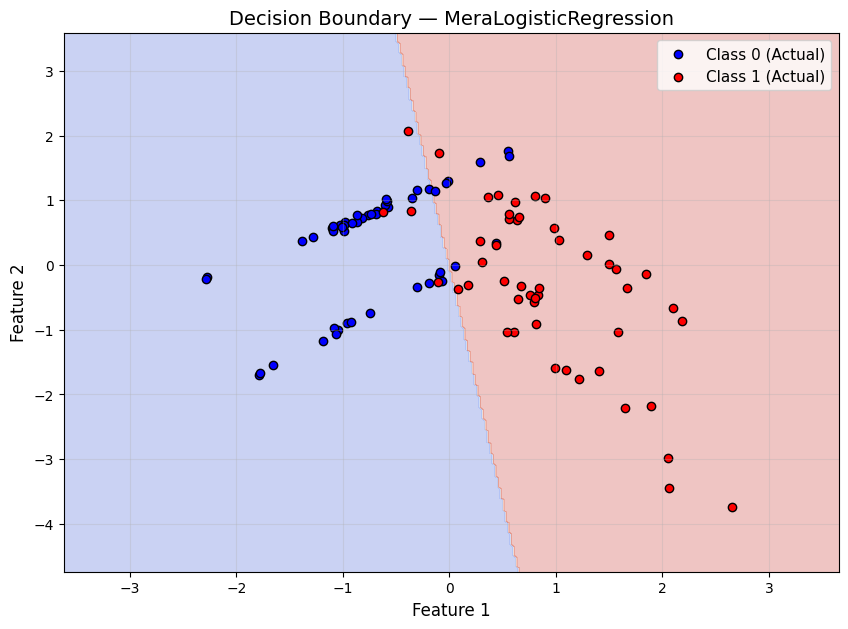

In [16]:
# Create a grid of points covering the entire feature space
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

# Predict the class for every single point on the grid
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
grid_predictions = my_model.predict(grid_points).reshape(xx1.shape)

# Plot!
plt.figure(figsize=(10, 7))

# Color the background based on the model's predictions
plt.contourf(xx1, xx2, grid_predictions, alpha=0.3, cmap='coolwarm')

# Overlay the actual test data points
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='blue', edgecolors='k', label='Class 0 (Actual)')
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='red',  edgecolors='k', label='Class 1 (Actual)')

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Decision Boundary — MeraLogisticRegression', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

The colored regions show where the model predicts Class 0 (blue) vs. Class 1 (red). The sharp line separating them is the **Decision Boundary**. Ideally, all blue dots should be in the blue zone and all red dots should be in the red zone!

---
## 11. Summary

| Concept | Linear Regression | Logistic Regression |
|---|---|---|
| **Output** | Any number ($-\infty$ to $+\infty$) | Probability (0 to 1) |
| **Used for** | Predicting quantities (price, revenue) | Predicting categories (win/loss, spam/not) |
| **Equation** | $\hat{y} = X\theta$ | $\hat{y} = \sigma(X\theta)$ |
| **Loss Function** | MSE | Binary Cross-Entropy (Log Loss) |
| **Training** | Gradient Descent / Normal Equation | Gradient Descent only |
| **Decision** | Direct output | If $\hat{y} \geq 0.5$: Class 1, else Class 0 |